In [1]:
# Install packages (uncomment if environment lacks them)
# !pip -q install pandas numpy statsmodels prophet holidays matplotlib seaborn scikit-learn xgboost

In [2]:
# Imports and configuration

import json
import warnings
from pathlib import Path
from typing import Callable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import holidays as pyholidays

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

try:
    from prophet import Prophet
except Exception:
    Prophet = None

try:
    from xgboost import XGBRegressor
except Exception:
    XGBRegressor = None

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# Deployment horizon (what the business cares about)
FORECAST_HORIZON = 12
# Backtest at the deployment horizon.
BACKTEST_HORIZON = 12
HORIZON_LABEL = f"h{BACKTEST_HORIZON}"
INITIAL_TRAIN_MONTHS = 24
ROLLING_STEP = 1
START_DATE = "2022-01-01"

# Stability guardrail: a point forecast is treated as runaway if any value is
# non-finite or exceeds `SANITY_CAP_MULTIPLIER * max(train)`. Runaway forecasts
# fall back to the seasonal-average baseline so they neither win selection nor
# corrupt ensembles.
SANITY_CAP_MULTIPLIER = 10.0

# Targets we actually care about. Segments and account are out of scope.
# `weighted_enquiry_value` = enquiry value * conversion probability, so this
# is an expected (risk-adjusted) pipeline value rather than the raw total.
TARGETS = ["enquiry_count_all", "weighted_enquiry_value"]

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "requirements.txt").exists() and (PROJECT_ROOT.parent / "requirements.txt").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

NOTEBOOK_DIR = PROJECT_ROOT / "data"
INPUT_CSV = NOTEBOOK_DIR / "enquiry_training_raw_20260421_132507.csv"

if not INPUT_CSV.exists():
    raise FileNotFoundError(f"Expected input CSV at: {INPUT_CSV}")

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "enquiry_value_forecast"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Input CSV:", INPUT_CSV)
print("Prophet available:", Prophet is not None)
print("XGBoost available:", XGBRegressor is not None)
print("Output directory:", OUTPUT_DIR)
print("Forecast horizon:", FORECAST_HORIZON)
print("Backtest horizon:", BACKTEST_HORIZON)
print("Initial train months:", INITIAL_TRAIN_MONTHS)
print("Rolling step:", ROLLING_STEP)

c:\Users\SamuelOjuri\OneDrive - Tapered Plus\Documents\CodeProjects\ML-Test\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: c:\Users\SamuelOjuri\OneDrive - Tapered Plus\Documents\CodeProjects\ML-Test
Input CSV: c:\Users\SamuelOjuri\OneDrive - Tapered Plus\Documents\CodeProjects\ML-Test\data\enquiry_training_raw_20260421_132507.csv
Prophet available: True
XGBoost available: True
Output directory: c:\Users\SamuelOjuri\OneDrive - Tapered Plus\Documents\CodeProjects\ML-Test\outputs\enquiry_value_forecast
Forecast horizon: 12
Backtest horizon: 12
Initial train months: 24
Rolling step: 1


In [3]:
# Extract the raw project-level dataset and build the overall monthly series.
# The last calendar month is dropped if its final day is not represented in
# the raw data, because partial months would bias both the forecast and the
# empirical residual bands downward.

raw_df = pd.read_csv(INPUT_CSV)

raw_df["date_created"] = pd.to_datetime(
    raw_df["date_created"], format="mixed", dayfirst=True, errors="coerce"
)
raw_df["new_enquiry_value"] = pd.to_numeric(raw_df["new_enquiry_value"], errors="coerce").fillna(0.0)
raw_df["weighted_enquiry_value"] = pd.to_numeric(raw_df["weighted_enquiry_value"], errors="coerce").fillna(0.0)
raw_df["has_positive_value"] = (
    pd.to_numeric(raw_df["has_positive_value"], errors="coerce").fillna(0).astype(int)
)

raw_df = raw_df[raw_df["date_created"] >= pd.Timestamp(START_DATE)].copy()
raw_df["enquiry_month"] = raw_df["date_created"].dt.to_period("M").dt.to_timestamp()

print("Raw rows:", len(raw_df))
print("Date range:", raw_df["date_created"].min().date(), "->", raw_df["date_created"].max().date())

raw_df.head()

Raw rows: 6864
Date range: 2022-01-04 -> 2026-04-21


,project_id,item_name,project_name,date_created,enquiry_month,new_enquiry_value,gross_enquiry_value,has_positive_value,expected_conversion_rate,conversion_confidence,...,product_type_raw,value_band,pipeline_stage,status_category,zip_code,sales_representative,funding,analysis_timestamp,created_at,updated_at
1565,1775779400,11533,"SGN Depot, Horley Holder Site, Off Balcombe Ro...",2022-01-04,2022-01-01,33830.96,33830.96,1,0.16,1.00,...,Tissue Faced PIR,Medium (15-40k),Lost,Lost,RH,Eddie Bushe,Unknown,2026-03-31 01:27:44.920636+00:00,2025-09-13 17:56:27.602389+00:00,2026-03-30 17:23:58.976126+00:00
1566,1776934482,8625,73 Kenilworth Road,2022-01-04,2022-01-01,0.00,0.00,0,0.12,0.44,...,Tissue Faced PIR,Zero,Won - Closed (Invoiced),Won,Unknown,Unknown,Unknown,2026-03-31 01:36:29.381476+00:00,2025-09-15 00:20:40.834067+00:00,2026-03-30 17:25:42.646080+00:00
1567,1776934928,8624,86 Old Eign Hill Hereford,2022-01-04,2022-01-01,1346.95,1346.95,1,0.20,1.00,...,VIPs,Small (<15k),Lost,Lost,HR,Ian Sumner,Unknown,2026-03-31 01:36:30.089042+00:00,2025-09-15 00:20:40.834067+00:00,2026-03-30 17:25:42.752292+00:00
1568,1776936134,8622,"Abingdon School Boarding House, Park Road, Abi...",2022-01-04,2022-01-01,22953.29,22953.29,1,0.17,0.57,...,ROCKWOOL HardRock Multi-Fix (DD),Medium (15-40k),Open Enquiry,Open,OX,Eddie Bushe,Unknown,2026-04-15 17:09:17.736924+00:00,2025-09-15 00:20:40.834067+00:00,2026-04-15 17:09:05.318576+00:00
1569,1776931533,8633,"Prior Park School, Bath",2022-01-05,2022-01-01,20340.81,20340.81,1,0.19,1.00,...,Tissue Faced PIR,Medium (15-40k),Lost,Lost,Unknown,Deleted Devon Brown,Unknown,2026-03-31 01:36:27.676976+00:00,2025-09-15 00:05:05.906205+00:00,2026-03-30 17:25:42.310679+00:00


In [4]:
# Build the overall monthly dataset only (segments removed from scope).

def build_overall_monthly(raw_frame: pd.DataFrame) -> pd.DataFrame:
    agg = (
        raw_frame.groupby("enquiry_month", as_index=False)
        .agg(
            enquiry_count_all=("project_id", "count"),
            enquiry_count_valued=("has_positive_value", "sum"),
            weighted_enquiry_value=("weighted_enquiry_value", "sum"),
        )
    )
    all_months = pd.date_range(
        agg["enquiry_month"].min(), agg["enquiry_month"].max(), freq="MS"
    )
    monthly = pd.DataFrame({"enquiry_month": all_months}).merge(
        agg, on="enquiry_month", how="left"
    )
    for col in ["enquiry_count_all", "enquiry_count_valued", "weighted_enquiry_value"]:
        monthly[col] = pd.to_numeric(monthly[col], errors="coerce").fillna(0.0)
    monthly["enquiry_count_all"] = monthly["enquiry_count_all"].astype(int)
    monthly["enquiry_count_valued"] = monthly["enquiry_count_valued"].astype(int)
    return monthly.sort_values("enquiry_month").reset_index(drop=True)


def drop_partial_last_month(monthly: pd.DataFrame, raw: pd.DataFrame) -> pd.DataFrame:
    last_month = monthly["enquiry_month"].max()
    month_end = (last_month + pd.offsets.MonthEnd(0)).normalize()
    latest_raw_date = raw["date_created"].max().normalize()
    if latest_raw_date < month_end:
        print(f"Dropping partial last month {last_month.date()} "
              f"(raw data ends on {latest_raw_date.date()}).")
        return monthly[monthly["enquiry_month"] < last_month].reset_index(drop=True)
    return monthly


overall_monthly = drop_partial_last_month(build_overall_monthly(raw_df), raw_df)
overall_monthly.to_csv(OUTPUT_DIR / "overall_monthly.csv", index=False)

print("Monthly rows:", len(overall_monthly))
overall_monthly.head()

Dropping partial last month 2026-04-01 (raw data ends on 2026-04-21).
Monthly rows: 51


,enquiry_month,enquiry_count_all,enquiry_count_valued,weighted_enquiry_value
0,2022-01-01,123,94,358148.6598
1,2022-02-01,157,111,909122.8092
2,2022-03-01,176,138,437571.4248
3,2022-04-01,147,111,404561.5756
4,2022-05-01,193,144,642002.2067


In [5]:
# Exploratory data analysis

print("Raw rows:", len(raw_df))
print("Unique accounts:", raw_df["account"].nunique())
print("Unique types:", raw_df["type"].nunique())
print("Unique categories:", raw_df["category"].nunique())
print("Unique product keys:", raw_df["product_key"].nunique())

overall_monthly[["enquiry_count_all", "weighted_enquiry_value"]].describe().T

Raw rows: 6864
Unique accounts: 959
Unique types: 3
Unique categories: 14
Unique product keys: 13


,count,mean,std,min,25%,50%,75%,max
enquiry_count_all,51.0,132.686275,28.077386,80.0000,112.00000,130.0000,155.0000,1.930000e+02
weighted_enquiry_value,51.0,803741.771382,324714.703668,358148.6598,582048.19335,780542.9635,913147.8397,2.209228e+06


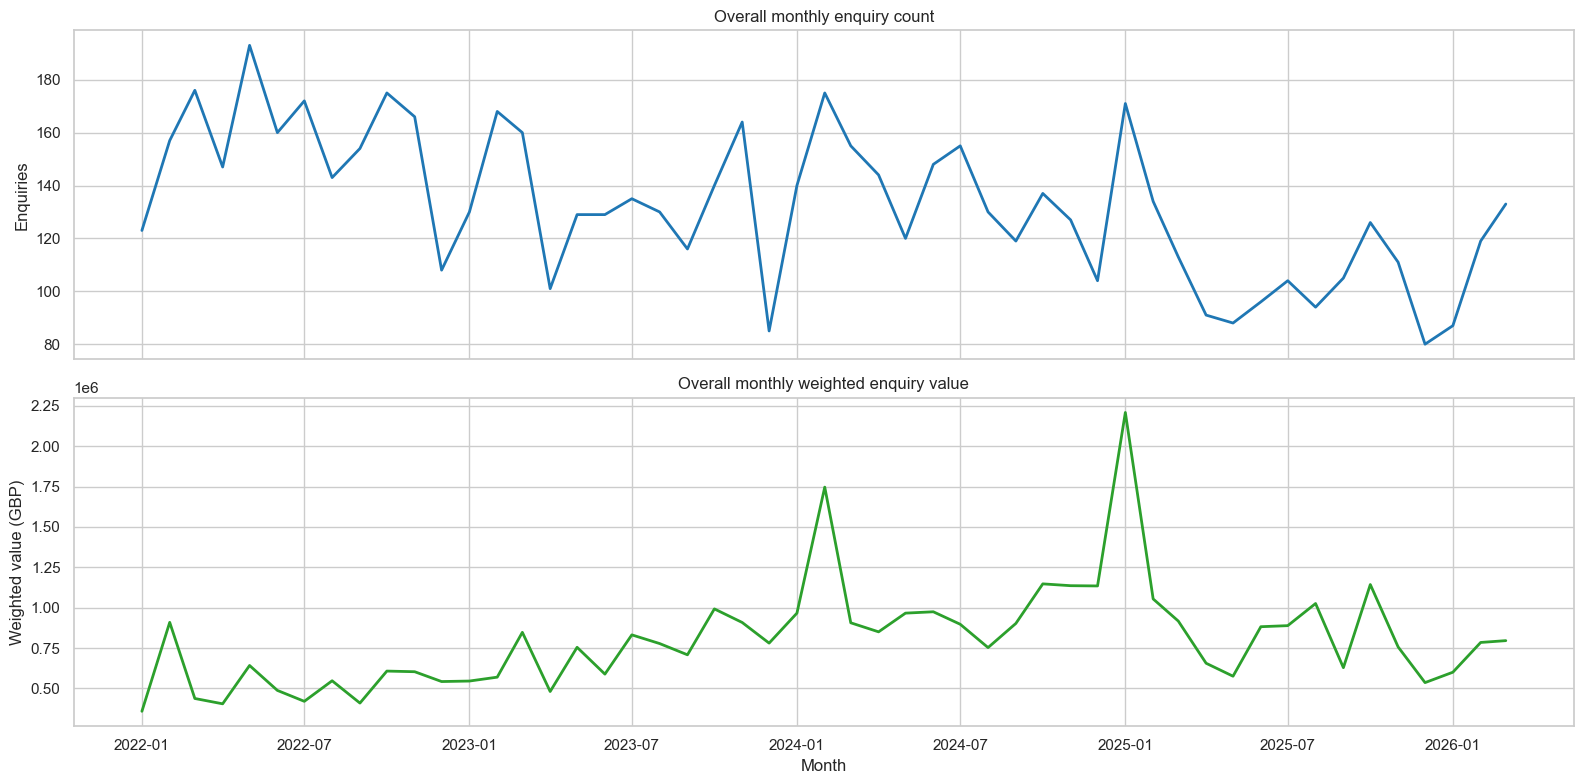

In [6]:
# Plot the overall historical series

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
axes[0].plot(overall_monthly["enquiry_month"], overall_monthly["enquiry_count_all"],
             color="tab:blue", linewidth=2)
axes[0].set_title("Overall monthly enquiry count")
axes[0].set_ylabel("Enquiries")

axes[1].plot(overall_monthly["enquiry_month"], overall_monthly["weighted_enquiry_value"],
             color="tab:green", linewidth=2)
axes[1].set_title("Overall monthly weighted enquiry value")
axes[1].set_ylabel("Weighted value (GBP)")
axes[1].set_xlabel("Month")

plt.tight_layout()
plt.show()

In [20]:
# Forecasting toolkit: forecasters, honest h-step rolling backtest,
# horizon-aware empirical intervals, model selection, and numerical
# guardrails so unstable fits cannot corrupt downstream results.

# --- exogenous regressors ------------------------------------------------

def build_monthly_exog(index: pd.DatetimeIndex) -> pd.DataFrame:
    """Monthly regressors: UK (England) working-day count and bank-holiday count."""
    start = index.min()
    end = (index.max() + pd.offsets.MonthEnd(0)).normalize()
    daily = pd.date_range(start, end, freq="D")
    years = sorted({ts.year for ts in daily})
    uk_hols = pyholidays.country_holidays("GB", subdiv="ENG", years=years)
    hol_set = {pd.Timestamp(d) for d in uk_hols.keys()}

    is_weekday = daily.weekday < 5
    is_holiday = np.array([ts in hol_set for ts in daily])
    is_workday = is_weekday & ~is_holiday

    month_key = daily.to_period("M").to_timestamp()
    # NB: column names must NOT clash with Prophet's reserved names
    # ("y", "ds", "cap", "floor", "holidays", "trend", ...).
    exog = (
        pd.DataFrame({
            "month": month_key,
            "workdays": is_workday.astype(int),
            "holiday_count": is_holiday.astype(int),
        })
        .groupby("month", as_index=True)
        .sum()
    )
    exog = exog.reindex(index, fill_value=0).astype(float)
    return exog


# --- helpers -------------------------------------------------------------

def non_negative(series: pd.Series) -> pd.Series:
    return pd.Series(np.clip(np.asarray(series, dtype=float), 0.0, None), index=series.index)


def safe_log1p(x: np.ndarray) -> np.ndarray:
    return np.log1p(np.clip(x, 0.0, None))


def is_sane_forecast(pred_values: np.ndarray, train: pd.Series,
                     cap_multiplier: float = SANITY_CAP_MULTIPLIER) -> bool:
    """Return True iff the forecast is finite and not runaway."""
    vals = np.asarray(pred_values, dtype=float)
    if vals.size == 0 or not np.all(np.isfinite(vals)):
        return False
    train_max = float(train.max()) if len(train) else 0.0
    cap = max(train_max * cap_multiplier, 1.0)
    if np.any(vals > cap):
        return False
    return True


def build_lagged_design_matrix(series: pd.Series, lags: tuple[int, ...],
                               exog: pd.DataFrame | None = None) -> tuple[pd.DataFrame, pd.Series]:
    frame = pd.DataFrame(index=series.index)
    for lag in sorted({int(lag) for lag in lags}):
        frame[f"lag_{lag}"] = series.shift(lag)
    if exog is not None:
        aligned_exog = exog.reindex(series.index).astype(float)
        for col in aligned_exog.columns:
            frame[col] = aligned_exog[col]
    valid = frame.notna().all(axis=1)
    return frame.loc[valid], series.loc[valid]


WEIGHTED_VALUE_XGB_CONFIG = {
    "lags": (1, 2, 3, 6, 9, 12),
    "rolling_windows": (3, 6),
    "max_depth": 1,
    "n_estimators": 700,
    "learning_rate": 0.02,
    "subsample": 0.9,
    "colsample_bytree": 0.85,
    "min_child_weight": 6.0,
    "reg_lambda": 6.0,
    "reg_alpha": 0.25,
    "use_exog": True,
    "add_month_features": True,
    "use_log": True,
}


def build_xgb_feature_matrix(series: pd.Series, lags: tuple[int, ...],
                             rolling_windows: tuple[int, ...] = (),
                             exog: pd.DataFrame | None = None,
                             add_month_features: bool = False) -> tuple[pd.DataFrame, pd.Series]:
    frame = pd.DataFrame(index=series.index)
    for lag in sorted({int(lag) for lag in lags}):
        frame[f"lag_{lag}"] = series.shift(lag)

    shifted = series.shift(1)
    for window in sorted({int(window) for window in rolling_windows}):
        frame[f"roll_mean_{window}"] = shifted.rolling(window).mean()
        frame[f"roll_std_{window}"] = shifted.rolling(window).std(ddof=0).fillna(0.0)

    if add_month_features:
        frame["month_sin"] = np.sin(2 * np.pi * series.index.month / 12.0)
        frame["month_cos"] = np.cos(2 * np.pi * series.index.month / 12.0)

    if exog is not None:
        aligned_exog = exog.reindex(series.index).astype(float)
        for col in aligned_exog.columns:
            frame[col] = aligned_exog[col]

    valid = frame.notna().all(axis=1)
    return frame.loc[valid], series.loc[valid]


def build_xgb_feature_row(history: pd.Series, ts: pd.Timestamp,
                          lags: tuple[int, ...],
                          rolling_windows: tuple[int, ...] = (),
                          exog_row: pd.Series | None = None,
                          add_month_features: bool = False,
                          exog_columns: tuple[str, ...] = ()) -> dict[str, float]:
    row: dict[str, float] = {}
    for lag in sorted({int(lag) for lag in lags}):
        lag_ts = ts - pd.DateOffset(months=lag)
        if lag_ts not in history.index:
            raise KeyError(f"Missing lag {lag} for {ts}")
        row[f"lag_{lag}"] = float(history.loc[lag_ts])

    for window in sorted({int(window) for window in rolling_windows}):
        window_values = []
        for step in range(1, window + 1):
            hist_ts = ts - pd.DateOffset(months=step)
            if hist_ts not in history.index:
                raise KeyError(f"Missing rolling value {step} for {ts}")
            window_values.append(float(history.loc[hist_ts]))
        row[f"roll_mean_{window}"] = float(np.mean(window_values))
        row[f"roll_std_{window}"] = float(np.std(window_values, ddof=0))

    if add_month_features:
        row["month_sin"] = float(np.sin(2 * np.pi * ts.month / 12.0))
        row["month_cos"] = float(np.cos(2 * np.pi * ts.month / 12.0))

    for col in exog_columns:
        row[col] = float(exog_row[col]) if exog_row is not None and col in exog_row.index else 0.0

    return row


# --- metrics -------------------------------------------------------------

def _rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float); y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def _mae(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float); y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean(np.abs(y_true - y_pred)))


def _mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float); y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true != 0
    if mask.sum() == 0:
        return float("nan")
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)


def _smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float); y_pred = np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true) + np.abs(y_pred)
    mask = denom != 0
    if mask.sum() == 0:
        return float("nan")
    return float(np.mean(200 * np.abs(y_true[mask] - y_pred[mask]) / denom[mask]))


def _mase(y_true, y_pred, in_sample: pd.Series, m: int = 12):
    insample = in_sample.values.astype(float)
    if len(insample) <= m:
        return float("nan")
    scale = float(np.mean(np.abs(insample[m:] - insample[:-m])))
    if scale == 0:
        return float("nan")
    return float(np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred))) / scale)


# --- forecasters ---------------------------------------------------------

def seasonal_naive_forecast(train: pd.Series, future_index: pd.DatetimeIndex) -> pd.Series:
    train = train.astype(float)
    values = []
    for ts in future_index:
        past = ts - pd.DateOffset(years=1)
        if past in train.index:
            values.append(float(train.loc[past]))
        else:
            values.append(float(train.iloc[-12:].mean()) if len(train) >= 12 else float(train.mean()))
    return non_negative(pd.Series(values, index=future_index))


def seasonal_average_forecast(train: pd.Series, future_index: pd.DatetimeIndex,
                              lookback: int | None = None, month_bias: bool = False) -> pd.Series:
    train = train.astype(float)
    working = train.iloc[-lookback:] if lookback else train
    month_means = working.groupby(working.index.month).mean()
    global_mean = float(working.mean())
    pred = pd.Series(
        [month_means.get(ts.month, global_mean) for ts in future_index],
        index=future_index, dtype=float,
    )
    if month_bias and len(train) >= 24:
        fitted = pd.Series(
            [month_means.get(ts.month, global_mean) for ts in train.index],
            index=train.index, dtype=float,
        )
        bias = (train - fitted).groupby(train.index.month).mean()
        pred = pred + pd.Series(
            [bias.get(ts.month, 0.0) for ts in future_index],
            index=future_index, dtype=float,
        )
    return non_negative(pred)


def ets_forecast(train: pd.Series, future_index: pd.DatetimeIndex,
                 trend="add", damped=True, seasonal="add", use_log=False) -> pd.Series:
    train = train.astype(float)
    if seasonal == "mul" and (train <= 0).any():
        seasonal = "add"
    model_series = pd.Series(safe_log1p(train.values), index=train.index) if use_log else train
    fit = ExponentialSmoothing(
        model_series,
        trend=trend,
        damped_trend=damped if trend is not None else False,
        seasonal=seasonal,
        seasonal_periods=12,
        initialization_method="estimated",
    ).fit(optimized=True, use_brute=True)
    raw_pred = fit.forecast(len(future_index))
    if use_log:
        resid = model_series - fit.fittedvalues
        sigma2 = float(np.nanvar(resid, ddof=1)) if len(resid) > 1 else 0.0
        pred = np.expm1(np.asarray(raw_pred) + 0.5 * sigma2)
    else:
        pred = np.asarray(raw_pred)
    return non_negative(pd.Series(pred, index=future_index))


def sarimax_forecast(train: pd.Series, future_index: pd.DatetimeIndex,
                     order=(1, 1, 1), seasonal_order=(0, 1, 1, 12),
                     use_log=False, exog_train=None, exog_future=None) -> pd.Series:
    train = train.astype(float)
    model_series = pd.Series(safe_log1p(train.values), index=train.index) if use_log else train
    try:
        fit = SARIMAX(
            model_series,
            order=order,
            seasonal_order=seasonal_order,
            exog=exog_train,
            enforce_stationarity=False,
            enforce_invertibility=False,
        ).fit(disp=False, maxiter=200)
        raw_pred = fit.forecast(steps=len(future_index), exog=exog_future)
        if use_log:
            resid = fit.resid
            sigma2 = float(np.nanvar(resid, ddof=1)) if len(resid) > 1 else 0.0
            pred = np.expm1(np.asarray(raw_pred) + 0.5 * sigma2)
        else:
            pred = np.asarray(raw_pred)
        return non_negative(pd.Series(pred, index=future_index))
    except Exception:
        return seasonal_average_forecast(train, future_index)


def prophet_forecast(train: pd.Series, future_index: pd.DatetimeIndex,
                     exog_train=None, exog_future=None,
                     changepoint_prior_scale: float = 0.05,
                     seasonality_prior_scale: float = 10.0) -> pd.Series:
    if Prophet is None or len(train) < 24:
        return seasonal_average_forecast(train, future_index)
    train = train.astype(float)
    df = pd.DataFrame({"ds": train.index, "y": train.values.astype(float)})
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode="additive",
        changepoint_prior_scale=changepoint_prior_scale,
        seasonality_prior_scale=seasonality_prior_scale,
        interval_width=0.8,
    )
    model.add_country_holidays(country_name="UK")
    if exog_train is not None:
        for col in exog_train.columns:
            df[col] = exog_train[col].values
            model.add_regressor(col)
    try:
        model.fit(df)
    except Exception:
        return seasonal_average_forecast(train, future_index)
    future = pd.DataFrame({"ds": future_index})
    if exog_future is not None:
        for col in exog_future.columns:
            future[col] = exog_future[col].values
    fc = model.predict(future)
    return non_negative(pd.Series(fc["yhat"].values, index=future_index, dtype=float))


def xgboost_forecast(train: pd.Series, future_index: pd.DatetimeIndex,
                     lags=(1, 12), rolling_windows=(), max_depth=3,
                     n_estimators=300, learning_rate=0.05,
                     subsample=0.9, colsample_bytree=0.9,
                     min_child_weight=1.0, reg_lambda=1.0, reg_alpha=0.0,
                     use_exog=False, add_month_features=False, use_log=False,
                     exog_train=None, exog_future=None) -> pd.Series:
    train = train.astype(float)
    lags = tuple(sorted({int(lag) for lag in lags}))
    if XGBRegressor is None or len(train) <= max(lags):
        return seasonal_average_forecast(train, future_index)

    working_series = pd.Series(safe_log1p(train.values), index=train.index) if use_log else train
    train_exog = exog_train.reindex(train.index).astype(float) if use_exog and exog_train is not None else None
    future_exog = exog_future.reindex(future_index).astype(float) if use_exog and exog_future is not None else None

    X_train, y_train = build_xgb_feature_matrix(
        working_series,
        lags=lags,
        rolling_windows=rolling_windows,
        exog=train_exog,
        add_month_features=add_month_features,
    )
    if len(X_train) < 12:
        return seasonal_average_forecast(train, future_index)

    feature_columns = X_train.columns.tolist()
    exog_columns = tuple(train_exog.columns.tolist()) if train_exog is not None else tuple()
    model = XGBRegressor(
        objective="reg:squarederror",
        max_depth=max_depth,
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        min_child_weight=min_child_weight,
        reg_lambda=reg_lambda,
        reg_alpha=reg_alpha,
        random_state=42,
        n_jobs=1,
    )

    try:
        model.fit(X_train, y_train)
        history = working_series.copy()
        preds = []
        for ts in future_index:
            exog_row = None if future_exog is None or ts not in future_exog.index else future_exog.loc[ts]
            row = build_xgb_feature_row(
                history,
                ts,
                lags=lags,
                rolling_windows=rolling_windows,
                exog_row=exog_row,
                add_month_features=add_month_features,
                exog_columns=exog_columns,
            )
            step_frame = pd.DataFrame([row], index=[ts]).reindex(columns=feature_columns, fill_value=0.0)
            yhat = float(model.predict(step_frame)[0])
            history.loc[ts] = yhat
            preds.append(yhat)
        pred_values = np.expm1(np.asarray(preds)) if use_log else np.asarray(preds)
        return non_negative(pd.Series(pred_values, index=future_index))
    except Exception:
        return seasonal_average_forecast(train, future_index)


# --- candidate registry -------------------------------------------------
#
# XGBoost is included for both targets using the requested
# configurations below. The remaining candidate families and
# backtest/selection logic are unchanged.

def _combine_candidates(candidates: dict, members: tuple, reducer) -> Callable:
    """Ensemble reducer over member forecasts with per-member sanity guardrail.

    A member forecast that fails, is non-finite, or exceeds the sanity cap is
    silently dropped from the stack so a single bad fit cannot pollute the
    reducer output. If every member is unusable, fall back to the seasonal
    average baseline.
    """
    def _fn(train, future_index):
        stacked = []
        for name in members:
            try:
                yhat = candidates[name](train, future_index).reindex(future_index)
                vals = np.asarray(yhat.values, dtype=float)
                if not is_sane_forecast(vals, train):
                    continue
                stacked.append(vals)
            except Exception:
                continue
        if not stacked:
            return seasonal_average_forecast(train, future_index)
        return non_negative(pd.Series(reducer(np.vstack(stacked), axis=0), index=future_index))
    return _fn


def _build_candidates_weighted_value(exog_full: pd.DataFrame) -> dict[str, Callable]:
    """Weighted-value candidates with the tuned current-history XGBoost variant."""

    def _seasonal_naive(train, future_index):
        return seasonal_naive_forecast(train, future_index)

    def _seasonal_average_24(train, future_index):
        return seasonal_average_forecast(train, future_index, lookback=24, month_bias=False)

    def _ets_tuned(train, future_index):
        return ets_forecast(train, future_index, trend=None, damped=False,
                            seasonal=True, use_log=True)

    def _xgboost_tuned(train, future_index):
        ex_tr = exog_full.loc[train.index] if exog_full is not None and WEIGHTED_VALUE_XGB_CONFIG["use_exog"] else None
        ex_fu = exog_full.loc[future_index] if exog_full is not None and WEIGHTED_VALUE_XGB_CONFIG["use_exog"] else None
        return xgboost_forecast(
            train,
            future_index,
            exog_train=ex_tr,
            exog_future=ex_fu,
            **WEIGHTED_VALUE_XGB_CONFIG,
        )

    def _sarimax_tuned(train, future_index):
        ex_tr = exog_full.loc[train.index] if exog_full is not None else None
        ex_fu = exog_full.loc[future_index] if exog_full is not None else None
        return sarimax_forecast(
            train,
            future_index,
            order=(1, 0, 1),
            seasonal_order=(1, 0, 0, 12),
            use_log=True,
            exog_train=ex_tr,
            exog_future=ex_fu,
        )

    def _prophet_tuned(train, future_index):
        ex_tr = exog_full.loc[train.index] if exog_full is not None else None
        ex_fu = exog_full.loc[future_index] if exog_full is not None else None
        return prophet_forecast(
            train,
            future_index,
            exog_train=ex_tr,
            exog_future=ex_fu,
            changepoint_prior_scale=0.05,
            seasonality_prior_scale=5.0,
        )

    candidates = {
        "seasonal_naive": _seasonal_naive,
        "seasonal_average_24": _seasonal_average_24,
        "ets_tuned": _ets_tuned,
        "xgboost_tuned": _xgboost_tuned,
        "sarimax_tuned": _sarimax_tuned,
        "prophet_tuned": _prophet_tuned,
    }
    return candidates


def _build_candidates_enquiry_count(exog_full: pd.DataFrame) -> dict[str, Callable]:
    """Hand-picked candidates for enquiry_count_all with the requested XGBoost candidate."""
    use_log_light = True
    use_log_sarimax = True

    def _seasonal_naive(train, future_index):
        return seasonal_naive_forecast(train, future_index)

    def _seasonal_avg_24(train, future_index):
        return seasonal_average_forecast(train, future_index, lookback=24, month_bias=False)

    def _seasonal_avg_12_bias(train, future_index):
        return seasonal_average_forecast(train, future_index, lookback=12, month_bias=True)

    def _ets_add(train, future_index):
        return ets_forecast(train, future_index, trend="add", damped=True, seasonal="add",
                            use_log=use_log_light)

    def _ets_mul(train, future_index):
        return ets_forecast(train, future_index, trend="add", damped=True, seasonal="mul",
                            use_log=use_log_light)

    def _xgboost_tuned(train, future_index):
        return xgboost_forecast(
            train,
            future_index,
            lags=(1, 12),
            max_depth=3,
            n_estimators=300,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            use_exog=False,
            use_log=False,
        )

    def _sarimax_plain(train, future_index):
        return sarimax_forecast(train, future_index, order=(1, 1, 1),
                                seasonal_order=(0, 1, 1, 12), use_log=use_log_sarimax)

    def _sarimax_exog(train, future_index):
        ex_tr = exog_full.loc[train.index] if exog_full is not None else None
        ex_fu = exog_full.loc[future_index] if exog_full is not None else None
        return sarimax_forecast(train, future_index, order=(1, 1, 1),
                                seasonal_order=(0, 1, 1, 12), use_log=use_log_sarimax,
                                exog_train=ex_tr, exog_future=ex_fu)

    def _prophet_plain(train, future_index):
        return prophet_forecast(train, future_index, changepoint_prior_scale=0.05)

    def _prophet_exog(train, future_index):
        ex_tr = exog_full.loc[train.index] if exog_full is not None else None
        ex_fu = exog_full.loc[future_index] if exog_full is not None else None
        return prophet_forecast(train, future_index, exog_train=ex_tr, exog_future=ex_fu,
                                changepoint_prior_scale=0.05)

    candidates = {
        "seasonal_naive": _seasonal_naive,
        "seasonal_average_24": _seasonal_avg_24,
        "seasonal_average_12_bias": _seasonal_avg_12_bias,
        "ets_add_damped": _ets_add,
        "ets_mul_damped": _ets_mul,
        "xgboost_tuned": _xgboost_tuned,
        "sarimax": _sarimax_plain,
        "sarimax_exog": _sarimax_exog,
        "prophet": _prophet_plain,
        "prophet_exog": _prophet_exog,
    }

    complementary = ("ets_add_damped", "sarimax_exog", "prophet_exog")
    robust = ("seasonal_average_24", "ets_add_damped", "sarimax_exog")

    candidates["ensemble_median_3"] = _combine_candidates(candidates, complementary, np.median)
    candidates["ensemble_mean_3"] = _combine_candidates(candidates, complementary, np.mean)
    candidates["ensemble_robust_median"] = _combine_candidates(candidates, robust, np.median)

    def _naive_sa_blend(train, future_index, alpha: float = 0.7):
        sn = seasonal_naive_forecast(train, future_index).values
        sa = seasonal_average_forecast(train, future_index, lookback=24).values
        return non_negative(pd.Series(alpha * sn + (1 - alpha) * sa, index=future_index))

    candidates["naive_sa_blend"] = _naive_sa_blend
    return candidates


def build_candidates(target_name: str, exog_full: pd.DataFrame) -> dict[str, Callable]:
    if target_name == "weighted_enquiry_value":
        return _build_candidates_weighted_value(exog_full)
    return _build_candidates_enquiry_count(exog_full)


# --- backtest and scoring -----------------------------------------------

def rolling_origin_backtest(series: pd.Series, candidates: dict,
                            initial_train: int = INITIAL_TRAIN_MONTHS,
                            horizon: int = BACKTEST_HORIZON,
                            step: int = ROLLING_STEP) -> pd.DataFrame:
    """Rolling-origin multi-step backtest with a runaway-forecast guardrail.

    A candidate that raises, returns non-finite, or returns values more than
    `SANITY_CAP_MULTIPLIER * max(train)` is recorded as a fallback in the
    `source` column and replaced with the seasonal-average baseline. This
    stops (rare but damaging) SARIMAX blow-ups from corrupting scores.
    """
    series = series.asfreq("MS").fillna(0.0).astype(float)
    rows = []
    for train_end in range(initial_train, len(series) - horizon + 1, step):
        train = series.iloc[:train_end]
        test = series.iloc[train_end:train_end + horizon]
        future_index = test.index
        for model_name, forecaster in candidates.items():
            fallback_reason = None
            pred = None
            try:
                pred = forecaster(train, future_index).reindex(future_index)
                if not is_sane_forecast(pred.values, train):
                    fallback_reason = "runaway"
            except Exception:
                fallback_reason = "error"
            if fallback_reason is not None:
                pred = seasonal_average_forecast(train, future_index)
                source = f"{model_name}->seasonal_average ({fallback_reason})"
            else:
                source = model_name
            for h, (ts, actual, yhat) in enumerate(zip(future_index, test.values, pred.values), start=1):
                rows.append({
                    "model": model_name, "source": source,
                    "train_end": train.index.max(),
                    "date": ts, "h": int(h),
                    "actual": float(actual), "pred": float(yhat),
                })
    return pd.DataFrame(rows)


def score_backtest(preds: pd.DataFrame, series: pd.Series) -> pd.DataFrame:
    out = []
    for model_name, grp in preds.groupby("model"):
        y_true = grp["actual"].values
        y_pred = grp["pred"].values
        per_h = (
            grp.assign(err=lambda df: (df["actual"] - df["pred"]).abs())
               .groupby("h")["err"].mean().to_dict()
        )
        fallback_rate = float((grp["source"].astype(str) != model_name).mean())
        out.append({
            "model": model_name,
            f"rmse_{HORIZON_LABEL}": _rmse(y_true, y_pred),
            f"mae_{HORIZON_LABEL}": _mae(y_true, y_pred),
            f"mape_{HORIZON_LABEL}": _mape(y_true, y_pred),
            f"smape_{HORIZON_LABEL}": _smape(y_true, y_pred),
            f"mase_{HORIZON_LABEL}": _mase(y_true, y_pred, series, m=12),
            "fallback_rate": fallback_rate,
            "n_predictions": len(grp),
            **{f"mae_h{h}": per_h.get(h, np.nan) for h in range(1, BACKTEST_HORIZON + 1)},
        })
    return (
        pd.DataFrame(out)
        .sort_values([f"rmse_{HORIZON_LABEL}", f"mae_{HORIZON_LABEL}"], ascending=True)
        .reset_index(drop=True)
    )


# --- horizon-aware empirical intervals ----------------------------------

def empirical_interval(backtest_preds: pd.DataFrame, model_name: str,
                       future_index: pd.DatetimeIndex,
                       min_fold_obs: int = 3, shrink_at: int = 6,
                       z: float = 1.96):
    bt = backtest_preds[backtest_preds["model"] == model_name].copy()
    if bt.empty:
        return np.zeros(len(future_index)), np.zeros(len(future_index))
    bt["err"] = bt["actual"] - bt["pred"]
    global_std = float(bt["err"].std(ddof=1))
    if not np.isfinite(global_std):
        global_std = 0.0
    per_h_std = bt.groupby("h")["err"].std(ddof=1)
    per_h_n = bt.groupby("h")["err"].size()
    per_h_std = per_h_std.fillna(global_std)
    weights = np.clip(per_h_n / float(shrink_at), 0.0, 1.0)
    blended = weights * per_h_std + (1.0 - weights) * global_std
    blended = blended.where(per_h_n >= min_fold_obs, global_std)
    half = np.array([float(blended.get(h, global_std)) * z for h in range(1, len(future_index) + 1)])
    return half, blended.reindex(range(1, len(future_index) + 1)).values


def backtest_coverage(preds: pd.DataFrame, model_name: str, z: float = 1.96) -> float:
    bt = preds[preds["model"] == model_name].copy()
    if bt.empty:
        return float("nan")
    bt["err"] = bt["actual"] - bt["pred"]
    global_std = float(bt["err"].std(ddof=1))
    per_h = bt.groupby("h")["err"].std(ddof=1).fillna(global_std)
    bt["sd"] = bt["h"].map(per_h.to_dict()).fillna(global_std)
    return float(((bt["actual"] - bt["pred"]).abs() <= z * bt["sd"]).mean())


# --- final forecast ------------------------------------------------------

def final_forecast(series: pd.Series, forecaster: Callable, model_name: str,
                   backtest_preds: pd.DataFrame,
                   candidates: dict | None = None,
                   horizon: int = FORECAST_HORIZON) -> tuple[pd.DataFrame, str]:
    """Produce the final forecast with a safety net.

    Returns (forecast_df, effective_model_name). If the chosen forecaster
    returns non-finite or runaway values on the full series, the function
    falls back to the target-appropriate seasonal-average baseline
    so the deliverable stays sensible.
    """
    series = series.asfreq("MS").fillna(0.0).astype(float)
    future_index = pd.date_range(
        series.index.max() + pd.offsets.MonthBegin(1), periods=horizon, freq="MS"
    )
    effective = model_name
    try:
        pred = forecaster(series, future_index).reindex(future_index)
        if not is_sane_forecast(pred.values, series):
            raise ValueError("runaway final forecast")
    except Exception:
        fallback_label = "seasonal_average_24"
        if candidates is not None and fallback_label not in candidates and "seasonal_average_15" in candidates:
            fallback_label = "seasonal_average_15"

        fallback_fn = None
        if candidates is not None and fallback_label in candidates:
            fallback_fn = candidates[fallback_label]
        if fallback_fn is None:
            fallback_fn = (lambda tr, fi: seasonal_average_forecast(tr, fi, lookback=24))

        pred = fallback_fn(series, future_index).reindex(future_index)
        effective = f"{model_name}->{fallback_label}"

    lookup_name = effective.split("->")[-1]
    half, _ = empirical_interval(backtest_preds, lookup_name, future_index)
    return (
        pd.DataFrame({
            "date": future_index,
            "forecast": pred.values,
            "lower": np.clip(pred.values - half, 0.0, None),
            "upper": np.clip(pred.values + half, 0.0, None),
            "model": effective,
        }),
        effective,
    )


def plot_backtest(actual: pd.Series, preds: pd.DataFrame, models: list[str], title: str) -> None:
    plt.figure(figsize=(16, 5))
    plt.plot(actual.index, actual.values, color="black", linewidth=2, label="Actual")
    for m in models:
        line = (
            preds[preds["model"] == m]
            .groupby("date", as_index=True)["pred"].mean().sort_index()
        )
        if not line.empty:
            linestyle = ":" if m == "seasonal_naive" else "--" if m == "seasonal_average_15" else "-"
            plt.plot(
                line.index,
                line.values,
                linewidth=1.8,
                linestyle=linestyle,
                alpha=0.9,
                label=m,
            )
    plt.title(title); plt.xlabel("Month"); plt.ylabel("Value")
    plt.legend(); plt.tight_layout(); plt.show()


def plot_residual_diagnostics(preds: pd.DataFrame, model_name: str, title_prefix: str) -> None:
    best = preds[preds["model"] == model_name].copy()
    if best.empty:
        return
    best["residual"] = best["actual"] - best["pred"]
    best["month_name"] = pd.to_datetime(best["date"]).dt.strftime("%b")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    sns.histplot(best["residual"], bins=20, kde=True, ax=axes[0])
    axes[0].set_title(f"{title_prefix}: residual distribution")

    axes[1].scatter(best["pred"], best["actual"], alpha=0.7)
    lo = float(min(best["pred"].min(), best["actual"].min()))
    hi = float(max(best["pred"].max(), best["actual"].max()))
    axes[1].plot([lo, hi], [lo, hi], linestyle="--", color="red")
    axes[1].set_title(f"{title_prefix}: actual vs predicted")
    axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")

    month_order = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
    sns.boxplot(data=best, x="month_name", y="residual", order=month_order, ax=axes[2])
    axes[2].set_title(f"{title_prefix}: residual by month")
    axes[2].tick_params(axis="x", rotation=45)
    plt.tight_layout(); plt.show()


def plot_final_forecast(history: pd.Series, forecast_df: pd.DataFrame, title: str) -> None:
    plt.figure(figsize=(16, 5))
    plt.plot(history.index, history.values, color="black", linewidth=2, label="History")

    forecast_line = pd.concat(
        [
            history.iloc[[-1]],
            pd.Series(
                forecast_df["forecast"].to_numpy(),
                index=pd.to_datetime(forecast_df["date"]),
            ),
        ]
    )

    plt.plot(
        forecast_line.index,
        forecast_line.values,
        color="tab:blue",
        linewidth=2,
        label="Forecast",
    )

    plt.fill_between(
        forecast_df["date"],
        forecast_df["lower"],
        forecast_df["upper"],
        color="tab:blue",
        alpha=0.2,
        label="95% band",
    )
    plt.title(title)
    plt.xlabel("Month")
    plt.ylabel("Value")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [21]:
# Evaluate overall monthly enquiry count and weighted enquiry value
# at the true deployment horizon h=BACKTEST_HORIZON, using a rolling-origin
# expanding window and the runaway-forecast guardrail.

monthly_index = pd.DatetimeIndex(overall_monthly["enquiry_month"])
exog_index = pd.date_range(
    monthly_index.min(),
    monthly_index.max() + pd.DateOffset(months=FORECAST_HORIZON),
    freq="MS",
)
exog_full = build_monthly_exog(exog_index)

# ---- enquiry count -----------------------------------------------------
count_series = (
    overall_monthly.set_index("enquiry_month")["enquiry_count_all"]
    .astype(float).asfreq("MS").fillna(0.0)
)
count_candidates = build_candidates("enquiry_count_all", exog_full)
count_preds = rolling_origin_backtest(count_series, count_candidates,
                                      initial_train=INITIAL_TRAIN_MONTHS,
                                      horizon=BACKTEST_HORIZON, step=ROLLING_STEP)
count_scores = score_backtest(count_preds, count_series)
count_scores["coverage_95"] = count_scores["model"].apply(lambda m: backtest_coverage(count_preds, m))

# ---- weighted enquiry value -------------------------------------------
value_series = (
    overall_monthly.set_index("enquiry_month")["weighted_enquiry_value"]
    .astype(float).asfreq("MS").fillna(0.0)
)
value_candidates = build_candidates("weighted_enquiry_value", exog_full)
value_preds = rolling_origin_backtest(value_series, value_candidates,
                                      initial_train=INITIAL_TRAIN_MONTHS,
                                      horizon=BACKTEST_HORIZON, step=ROLLING_STEP)
value_scores = score_backtest(value_preds, value_series)
value_scores["coverage_95"] = value_scores["model"].apply(lambda m: backtest_coverage(value_preds, m))

count_scores.to_csv(OUTPUT_DIR / "overall_count_model_scores.csv", index=False)
value_scores.to_csv(OUTPUT_DIR / "overall_weighted_model_scores.csv", index=False)
count_preds.to_csv(OUTPUT_DIR / "overall_count_backtest_predictions.csv", index=False)
value_preds.to_csv(OUTPUT_DIR / "overall_weighted_backtest_predictions.csv", index=False)

display_cols = [
    "model",
    f"rmse_{HORIZON_LABEL}",
    f"mae_{HORIZON_LABEL}",
    f"mape_{HORIZON_LABEL}",
    f"smape_{HORIZON_LABEL}",
    f"mase_{HORIZON_LABEL}",
    "fallback_rate",
    "coverage_95",
]
print(f"Enquiry count (ranked by {HORIZON_LABEL} RMSE):")
display(count_scores[display_cols])
print(f"Weighted enquiry value (ranked by {HORIZON_LABEL} RMSE):")
display(value_scores[display_cols])

07:42:52 - cmdstanpy - INFO - Chain [1] start processing
07:43:08 - cmdstanpy - INFO - Chain [1] done processing
07:43:08 - cmdstanpy - INFO - Chain [1] start processing
07:43:11 - cmdstanpy - INFO - Chain [1] done processing
07:43:11 - cmdstanpy - INFO - Chain [1] start processing
07:43:14 - cmdstanpy - INFO - Chain [1] done processing
07:43:14 - cmdstanpy - INFO - Chain [1] start processing
07:43:17 - cmdstanpy - INFO - Chain [1] done processing
07:43:17 - cmdstanpy - INFO - Chain [1] start processing
07:43:32 - cmdstanpy - INFO - Chain [1] done processing
07:43:32 - cmdstanpy - INFO - Chain [1] start processing
07:43:34 - cmdstanpy - INFO - Chain [1] done processing
07:43:35 - cmdstanpy - INFO - Chain [1] start processing
07:43:37 - cmdstanpy - INFO - Chain [1] done processing
07:43:37 - cmdstanpy - INFO - Chain [1] start processing
07:43:39 - cmdstanpy - INFO - Chain [1] done processing
07:43:40 - cmdstanpy - INFO - Chain [1] start processing
07:43:40 - cmdstanpy - INFO - Chain [1]

Enquiry count (ranked by h12 RMSE):


,model,rmse_h12,mae_h12,mape_h12,smape_h12,mase_h12,fallback_rate,coverage_95
0,xgboost_tuned,29.120292,25.735791,22.449722,19.827026,0.930509,0.0000,0.937500
1,seasonal_average_24,31.144196,30.750000,24.618206,21.467859,1.045695,0.0000,0.963542
2,naive_sa_blend,32.473492,32.856250,25.520178,22.144320,1.068159,0.0000,0.958333
3,seasonal_naive,33.770287,33.812500,26.146439,22.614989,1.088710,0.0000,0.953125
4,ets_add_damped,34.237106,35.020688,26.302706,22.922760,1.122951,0.0000,0.916667
5,ets_mul_damped,34.652922,35.749149,26.710268,23.277607,1.138918,0.0000,0.911458
6,ensemble_robust_median,34.943134,34.792992,27.429943,23.283010,1.152605,0.0000,0.880208
7,seasonal_average_12_bias,35.735347,36.937500,28.756915,24.458956,1.203482,0.0000,0.854167
8,ensemble_median_3,37.519582,32.685225,28.612833,24.400021,1.228240,0.0000,0.875000
9,prophet,41.626728,22.014312,27.965478,27.901665,1.267791,0.0000,0.932292


Weighted enquiry value (ranked by h12 RMSE):


,model,rmse_h12,mae_h12,mape_h12,smape_h12,mase_h12,fallback_rate,coverage_95
0,xgboost_tuned,407904.249596,367479.427763,29.862641,26.764812,0.845476,0.0,0.927083
1,seasonal_average_24,477919.664169,337973.202381,30.900354,33.665536,0.987027,0.0,0.927083
2,seasonal_naive,484321.815401,407250.093600,33.960932,31.122888,0.998292,0.0,0.911458
3,ets_tuned,489161.054082,291608.898343,30.012163,35.608405,1.011341,1.0,0.927083
4,prophet_tuned,721220.264582,654443.611900,65.634214,58.020448,1.770481,0.0,0.921875
5,sarimax_tuned,860271.028926,719942.789783,74.221677,50.897367,1.905883,0.0,0.906250


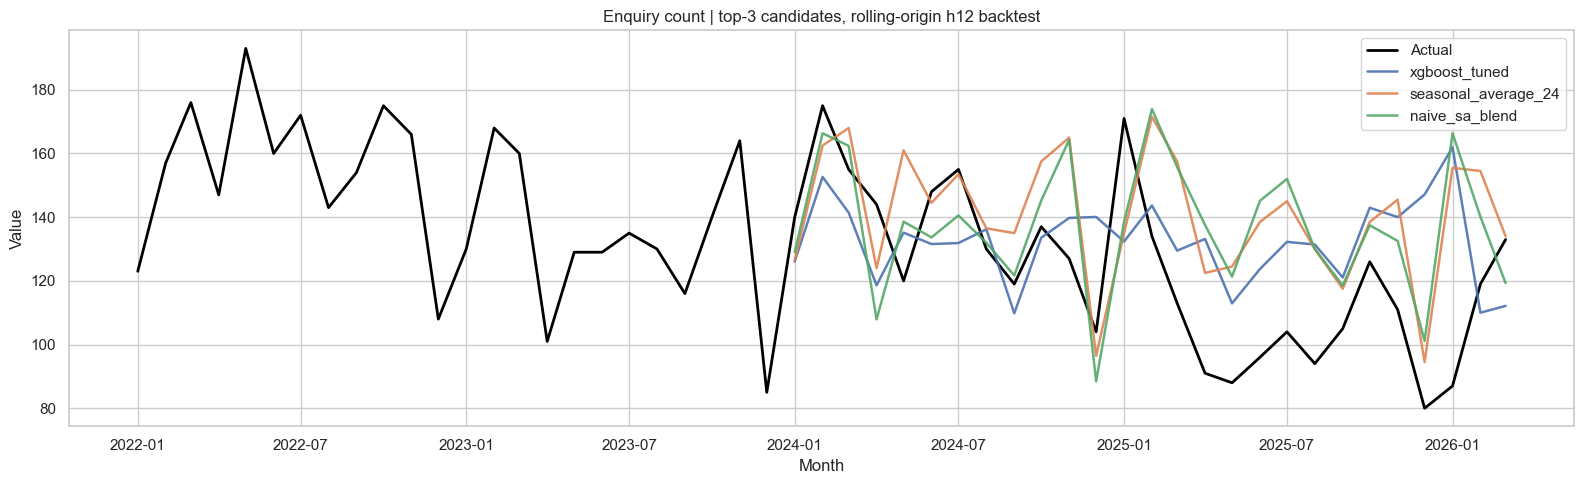

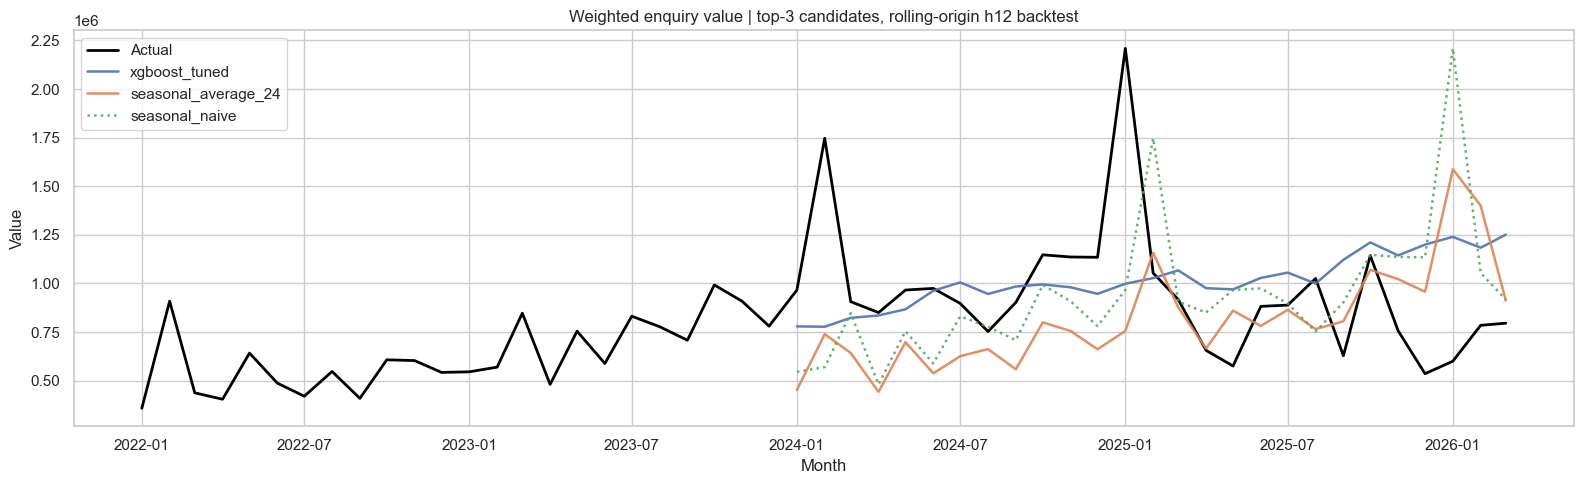

Best enquiry count model: xgboost_tuned
Backtest-ranked weighted enquiry value model: xgboost_tuned
Selected weighted enquiry value model: xgboost_tuned


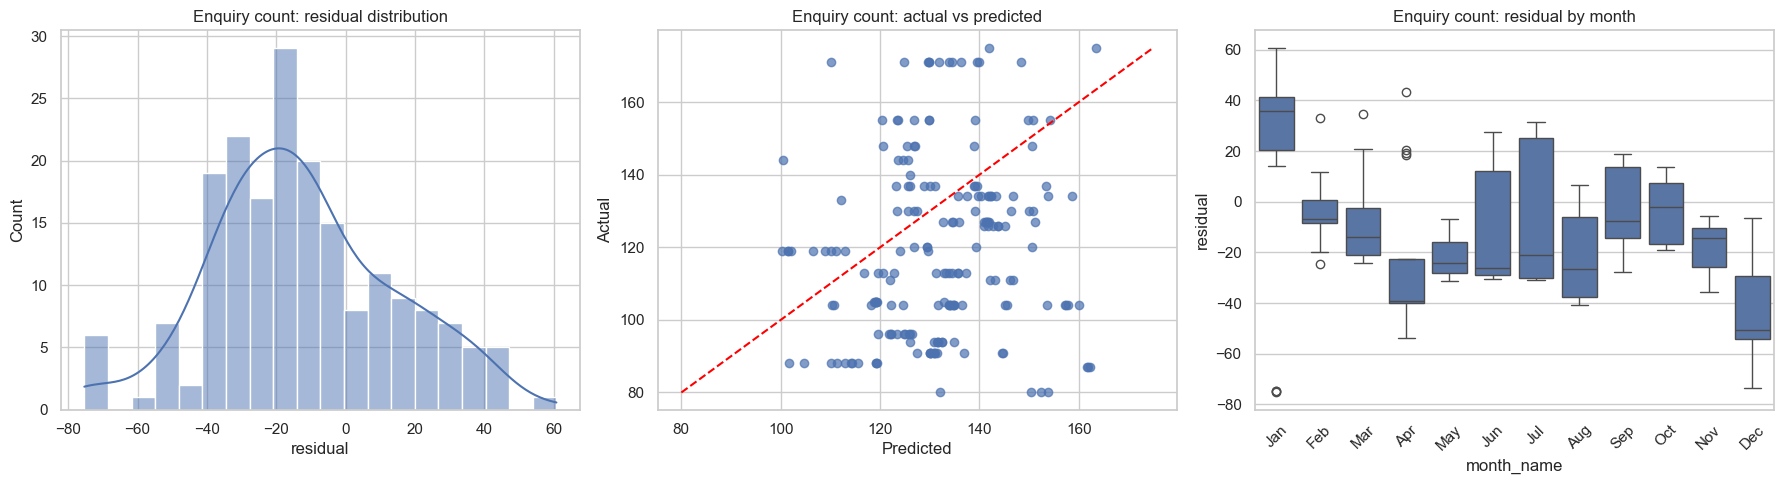

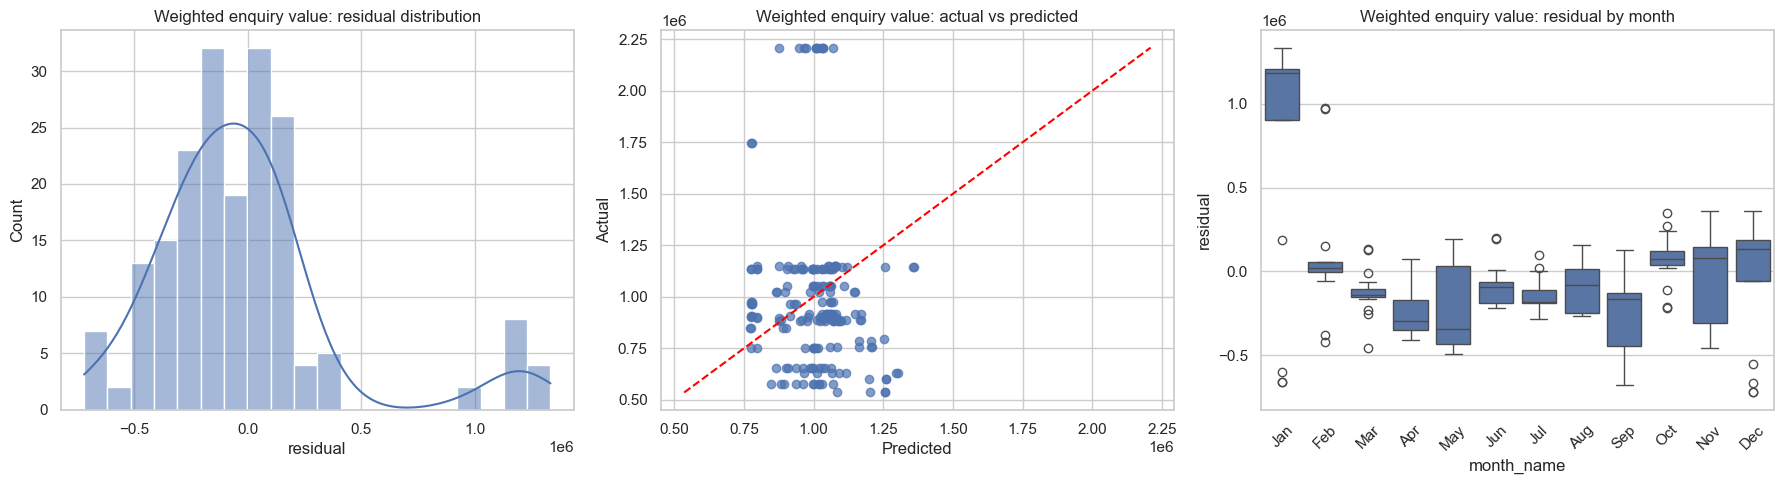

In [16]:
# Visual backtest diagnostics for the top-3 candidates per target, plus
# residual diagnostics for the winner.

top_count_models = count_scores["model"].head(3).tolist()
top_value_models = value_scores["model"].head(3).tolist()

plot_backtest(
    count_series, count_preds, top_count_models,
    f"Enquiry count | top-3 candidates, rolling-origin {HORIZON_LABEL} backtest",
)
plot_backtest(
    value_series, value_preds, top_value_models,
    f"Weighted enquiry value | top-3 candidates, rolling-origin {HORIZON_LABEL} backtest",
)

best_count_model = count_scores.iloc[0]["model"]
backtest_best_value_model = value_scores.iloc[0]["model"]
best_value_model = backtest_best_value_model
print("Best enquiry count model:", best_count_model)
print("Backtest-ranked weighted enquiry value model:", backtest_best_value_model)
print("Selected weighted enquiry value model:", best_value_model)

plot_residual_diagnostics(count_preds, best_count_model, "Enquiry count")
plot_residual_diagnostics(value_preds, best_value_model, "Weighted enquiry value")

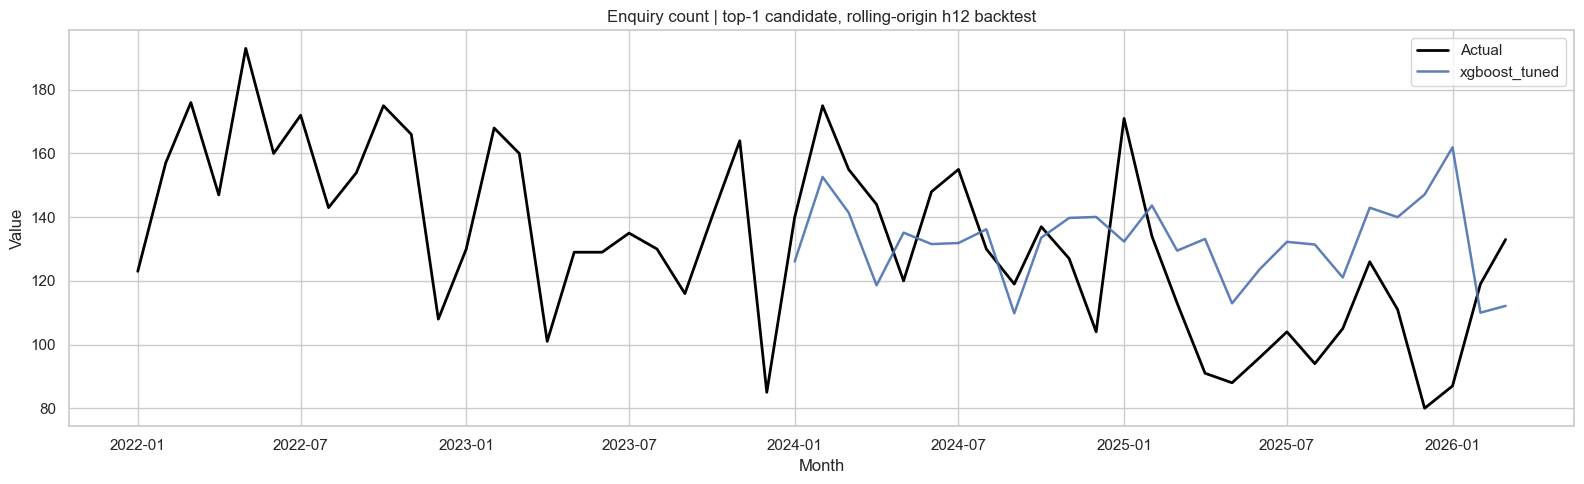

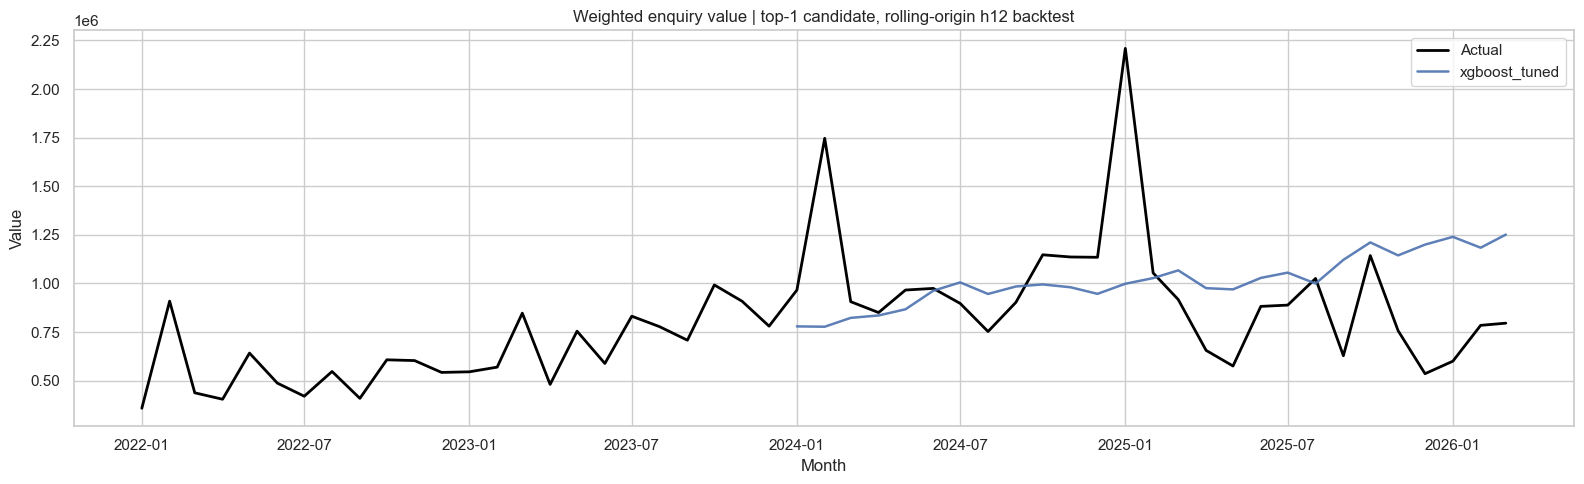

Best enquiry count model: xgboost_tuned
Backtest-ranked weighted enquiry value model: xgboost_tuned
Selected weighted enquiry value model: xgboost_tuned


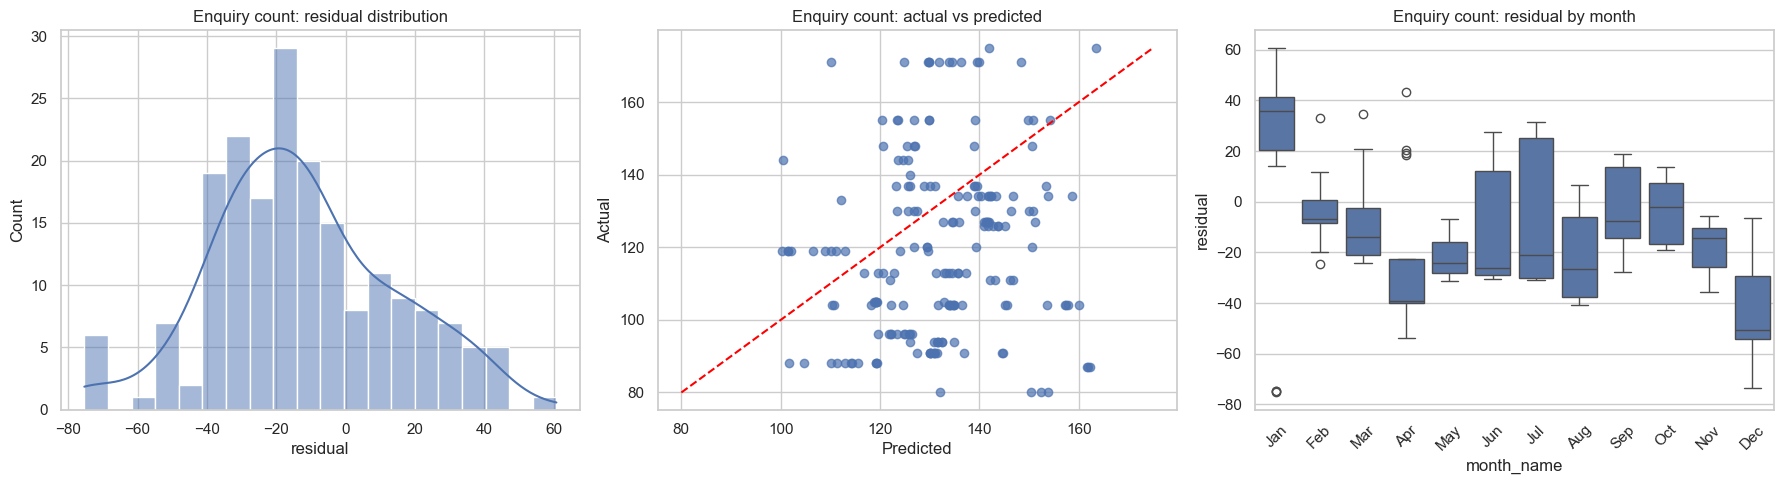

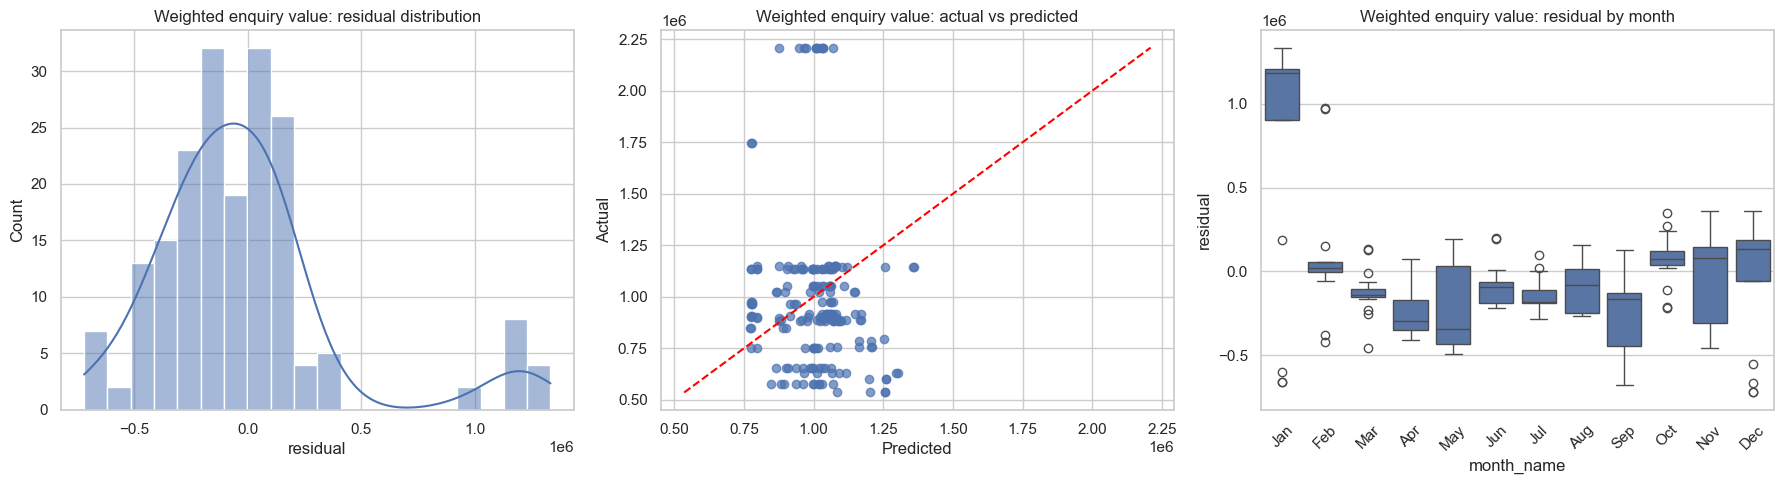

In [17]:
# Visual backtest diagnostics for the top candidates per target, plus
# residual diagnostics for the winner.

top_count_models = count_scores["model"].head(1).tolist()
top_value_models = value_scores["model"].head(1).tolist()

plot_backtest(
    count_series, count_preds, top_count_models,
    f"Enquiry count | top-1 candidate, rolling-origin {HORIZON_LABEL} backtest",
)
plot_backtest(
    value_series, value_preds, top_value_models,
    f"Weighted enquiry value | top-1 candidate, rolling-origin {HORIZON_LABEL} backtest",
)

best_count_model = count_scores.iloc[0]["model"]
backtest_best_value_model = value_scores.iloc[0]["model"]
best_value_model = backtest_best_value_model
print("Best enquiry count model:", best_count_model)
print("Backtest-ranked weighted enquiry value model:", backtest_best_value_model)
print("Selected weighted enquiry value model:", best_value_model)

plot_residual_diagnostics(count_preds, best_count_model, "Enquiry count")
plot_residual_diagnostics(value_preds, best_value_model, "Weighted enquiry value")

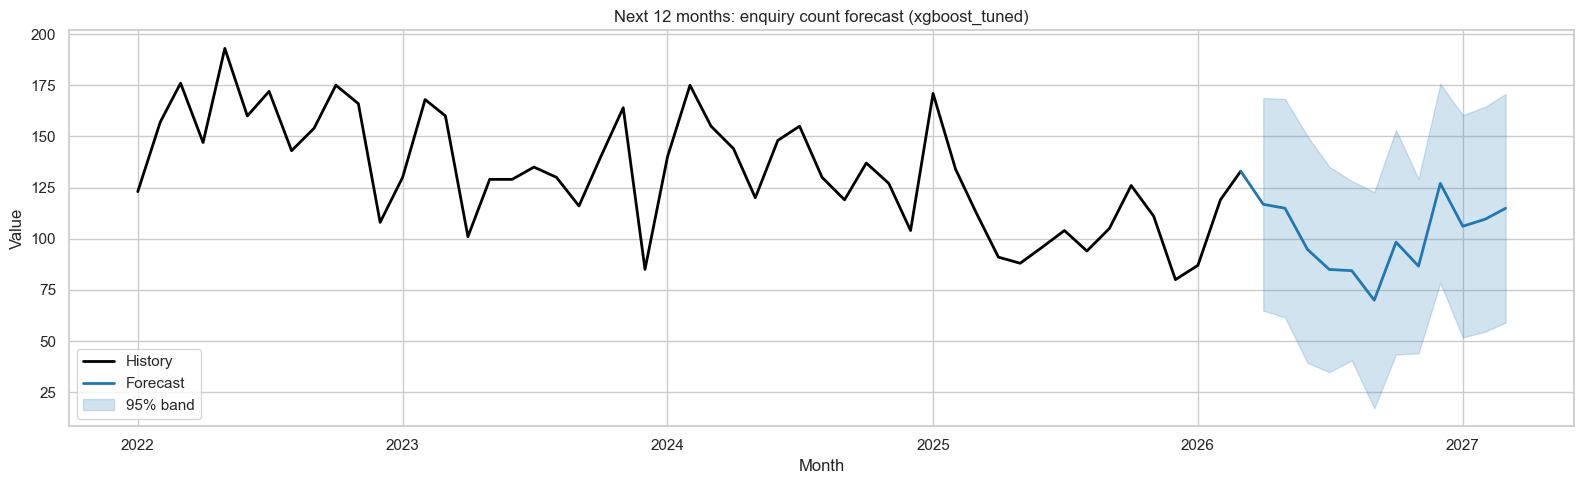

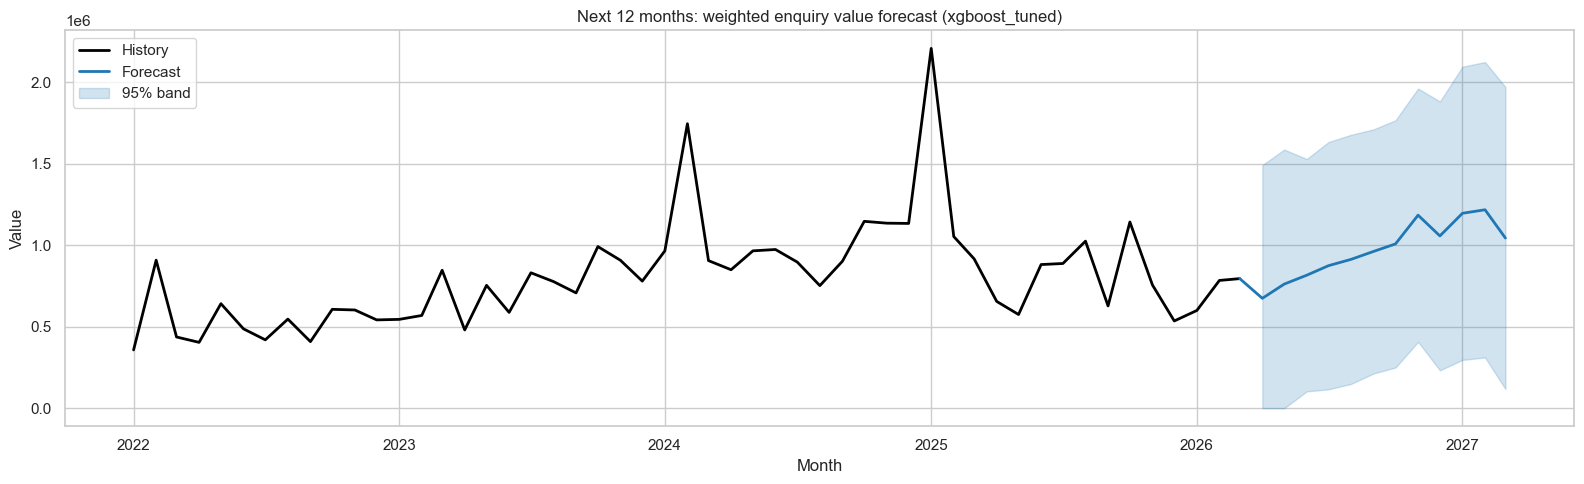

,date,forecast,lower,upper,model
0,2026-04-01,116.812561,64.859858,168.765264,xgboost_tuned
1,2026-05-01,114.886993,61.517006,168.256981,xgboost_tuned
2,2026-06-01,94.736755,39.354818,150.118692,xgboost_tuned
3,2026-07-01,84.966461,34.789531,135.143392,xgboost_tuned
4,2026-08-01,84.376892,40.532497,128.221287,xgboost_tuned
5,2026-09-01,69.936783,17.138194,122.735372,xgboost_tuned
6,2026-10-01,98.296852,43.419675,153.174029,xgboost_tuned
7,2026-11-01,86.601265,43.997227,129.205303,xgboost_tuned
8,2026-12-01,127.035133,78.430213,175.640053,xgboost_tuned
9,2027-01-01,106.070816,51.787386,160.354246,xgboost_tuned


,date,forecast,lower,upper,model
0,2026-04-01,6.749573e+05,0.000000,1.492562e+06,xgboost_tuned
1,2026-05-01,7.620944e+05,0.000000,1.588140e+06,xgboost_tuned
2,2026-06-01,8.168154e+05,103636.300129,1.529995e+06,xgboost_tuned
3,2026-07-01,8.754731e+05,116228.264271,1.634718e+06,xgboost_tuned
4,2026-08-01,9.142597e+05,149571.221345,1.678948e+06,xgboost_tuned
5,2026-09-01,9.630683e+05,213698.493810,1.712438e+06,xgboost_tuned
6,2026-10-01,1.009076e+06,250090.017652,1.768062e+06,xgboost_tuned
7,2026-11-01,1.185384e+06,407820.261843,1.962949e+06,xgboost_tuned
8,2026-12-01,1.057996e+06,232678.226132,1.883314e+06,xgboost_tuned
9,2027-01-01,1.197010e+06,296925.652103,2.097095e+06,xgboost_tuned


In [18]:
# Final h-month forecasts using the winning models selected by h-step RMSE.
# Prediction bands are horizon-aware empirical intervals derived from backtest
# residuals at the matching forecast step, clipped at zero.
# `final_forecast` additionally sanity-checks the chosen model on the full
# series and falls back to seasonal_average_24 if it produces runaway values.

count_forecast, count_effective = final_forecast(
    count_series, count_candidates[best_count_model], best_count_model,
    count_preds, candidates=count_candidates, horizon=FORECAST_HORIZON,
)
value_forecast, value_effective = final_forecast(
    value_series, value_candidates[best_value_model], best_value_model,
    value_preds, candidates=value_candidates, horizon=FORECAST_HORIZON,
)

count_forecast.to_csv(OUTPUT_DIR / "overall_count_forecast.csv", index=False)
value_forecast.to_csv(OUTPUT_DIR / "overall_weighted_forecast.csv", index=False)

if count_effective != best_count_model:
    print(f"NOTE: enquiry count forecast degraded from {best_count_model} to {count_effective}.")
if value_effective != best_value_model:
    print(f"NOTE: weighted value forecast degraded from {best_value_model} to {value_effective}.")

plot_final_forecast(
    count_series, count_forecast,
    f"Next {FORECAST_HORIZON} months: enquiry count forecast ({count_effective})",
)
plot_final_forecast(
    value_series, value_forecast,
    f"Next {FORECAST_HORIZON} months: weighted enquiry value forecast ({value_effective})",
)

display(count_forecast)
display(value_forecast)

In [19]:
# Save a compact model-selection summary for downstream consumers.

def _row(target, scores, preds, effective_model):
    backtest_best = scores.iloc[0]
    selected = scores[scores["model"] == effective_model]
    selected_row = selected.iloc[0] if not selected.empty else backtest_best
    return {
        "target": target,
        "best_model": selected_row["model"],
        "backtest_ranked_model": backtest_best["model"],
        "effective_model": effective_model,
        f"rmse_{HORIZON_LABEL}": selected_row[f"rmse_{HORIZON_LABEL}"],
        f"mae_{HORIZON_LABEL}": selected_row[f"mae_{HORIZON_LABEL}"],
        f"mape_{HORIZON_LABEL}": selected_row[f"mape_{HORIZON_LABEL}"],
        f"smape_{HORIZON_LABEL}": selected_row[f"smape_{HORIZON_LABEL}"],
        f"mase_{HORIZON_LABEL}": selected_row[f"mase_{HORIZON_LABEL}"],
        "fallback_rate": selected_row["fallback_rate"],
        "coverage_95": selected_row["coverage_95"],
        "n_predictions": selected_row["n_predictions"],
        "backtest_horizon": BACKTEST_HORIZON,
        "initial_train_months": INITIAL_TRAIN_MONTHS,
        "rolling_step": ROLLING_STEP,
    }

summary_df = pd.DataFrame([
    _row("enquiry_count_all", count_scores, count_preds, count_effective),
    _row("weighted_enquiry_value", value_scores, value_preds, value_effective),
])
summary_df.to_csv(OUTPUT_DIR / "overall_best_model_summary.csv", index=False)
display(summary_df)

,target,best_model,backtest_ranked_model,effective_model,rmse_h12,mae_h12,mape_h12,smape_h12,mase_h12,fallback_rate,coverage_95,n_predictions,backtest_horizon,initial_train_months,rolling_step
0,enquiry_count_all,xgboost_tuned,xgboost_tuned,xgboost_tuned,29.120292,25.735791,22.449722,19.827026,0.930509,0.0,0.937500,192,12,24,1
1,weighted_enquiry_value,xgboost_tuned,xgboost_tuned,xgboost_tuned,407904.249596,367479.427763,29.862641,26.764812,0.845476,0.0,0.927083,192,12,24,1
